## Setting things up

### Import libraries
Add directory with the CIBUSmod modules to path to be able to import

In [1]:
import sys
import os
sys.path.insert(0, os.path.join(os.getcwd(),'..'))

Import CIBUSmod and packages for handling data and plotting

In [2]:
import CIBUSmod as cm
from CIBUSmod.utils.output_data_manip import concat_herds, get_GHG
import CIBUSmod.utils.plot as plot

import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Set up scenario and modules

Set path to folders containing all default and scenario data. Select the 'baseline' scenario, define years to calculate output for and create a container to store outputs per year. To save time we use 10-year time steps, but 1-year time steps are also possible.

In [64]:
# Set paths to default and scenario data
cm.ParameterRetriever.set_data_folders(
    default = os.path.join('..','data','prod_parameters'),
    scenarios = os.path.join('..','data','scenarios'),
    relation_tables = os.path.join('..','data','relation_tables.xlsx')
)

# Define scenario, years and create output container
scn = 'none'
year = '2020'
output = pd.DataFrame(
    columns=['dem','crp','ani'],
    index=pd.MultiIndex.from_frame(pd.DataFrame({'scn':[scn],'year':[year]}))
)

In [65]:
# Instatiate Regions
regions = cm.Regions(
    par = cm.ParameterRetriever('Regions')
)

# Instantiate DemandAndConversions
demand = cm.DemandAndConversions(
    par = cm.ParameterRetriever('DemandAndConversions')
)

# Instantiate CropProduction
crops = cm.CropProduction(
    par = cm.ParameterRetriever('CropProduction'),
    index = regions.x0_crops.index
)    

# Instantiate AnimalHerds
# Each AnimalHerd object is stored in an indexed pandas.Series
herds = cm.make_herds(regions)

# Instantiate feed management
feed_mgmt = cm.FeedMgmt(
    herds = herds,
    par = cm.ParameterRetriever('FeedMgmt')
)

# Instantiate manure management
manure_mgmt = cm.ManureMgmt(
    herds = herds,
    par = cm.ParameterRetriever('ManureMgmt')
)

# Instantiate plant nutrient management
plant_nutrient_mgmt = cm.PlantNutrientMgmt(
    demand = demand,
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('PlantNutrientMgmt')
)

# Instatiate machinery and energy management
machinery_and_energy_mgmt  = cm.MachineryAndEnergyMgmt(
    regions = regions,
    crops = crops,
    herds = herds,
    par = cm.ParameterRetriever('MachineryAndEnergyMgmt')
)

# Instantiate geo distributor
geodist = cm.GeoDistributor(
    regions = regions,
    demand = demand,
    crops = crops,
    herds = herds,
    feed_mgmt = feed_mgmt,
    par = cm.ParameterRetriever('GeoDistributor')
)

In [66]:
# Get region attributes
regions.calculate(verbose=True)

# Calculate food demand
demand.calculate(verbose=True)

# Calculate crops
crops.calculate(
    verbose = True
)

# Calculate herds
for h in herds:
    h.calculate(verbose = True)

# Calculate feed
feed_mgmt.calculate(verbose=True)    

# Adjust animal demand to stat (CHECK DEMAND DATA TO ALIGN!!!)
demand.animal_prod_demand.update(
    pd.Series(
        {
            ('conventional','cattle','meat') : (136-21) * 1000000,
            ('organic','cattle','meat')      : 21 * 1000000,
            ('conventional','cattle','milk') : (2760-464) * 1000000,
            ('organic','cattle','milk')      : 464 * 1000000,
            ('conventional','pigs','meat')   : (249-6) * 1000000,
            ('organic','pigs','meat')        : 6 * 1000000,
            ('conventional','poultry','eggs')   : (117.49-23.38) * 1000000,
            ('organic','poultry','eggs')        : 23.38 * 1000000,
            ('conventional','poultry','meat')   : (152-1.432) * 1000000,
            ('organic','poultry','meat')        : 1.432 * 1000000,
        },
    )
    .rename('food')
    .rename_axis(['prod_system','species','animal_prod'])
)

# Distribute animals and crops
# Make optimisation problem
geodist.make(use_cons=[1,2,3,4,5,6,7], scale_power=0.6, verbose=True)
# Solve optimisation problem
geodist.solve(
    verbose=True,
    solver_settings = {
        'solver':'OSQP',
        'max_iter':200000,
        'eps_abs':5e-6,
        'eps_rel':5e-6,
        'verbose':False
    }
)

# Redistribute feeds (not yet implemented) and calculate enteric CH4 emissions
feed_mgmt.calculate2(verbose=True)

# Calculate manure
manure_mgmt.calculate(verbose=True)

# Calculate plant nutrient management
plant_nutrient_mgmt.calculate(verbose=True)

# Calculate energy requirements
machinery_and_energy_mgmt.calculate(verbose=True)

# Store results
# Demand
output.loc[(scn,year),'dem'] = \
demand.make_static()
# Crops
output.loc[(scn,year),'crp'] = \
crops.make_static()
# Animals
output.loc[(scn,year),'ani'] = \
concat_herds(
    herds.apply(lambda x: x.make_static())
)

[16:05:47][Regions] Getting initial crop areas and animal numbers (x0) ...
[16:05:47][Regions] Getting climate and soil attributes ...
[16:05:47][Regions] Done! Elapsed time: 0 sec
[16:05:47][DemandAndConversions] Calculating food demand ...
[16:05:47][DemandAndConversions] Calculating waste ...
[16:05:47][DemandAndConversions] Calculating crop product demand ...
[16:05:48][DemandAndConversions] Calculating animal product demand ...
[16:05:48][DemandAndConversions] Done! Elapsed time: 1 sec
[16:05:48][CropProduction] Calculating harvest ...
[16:05:48][CropProduction] Calculating production ...
[16:05:51][CropProduction] Calculating crop residues ...
[16:05:51][CropProduction] Calculating seed demand ...
[16:05:53][CropProduction] Done! Elapsed time: 4 sec
[16:05:53][AnimalHerd (cattle, beef, conventional, maize based)] Calculating herd structure ...
[16:05:53][AnimalHerd (cattle, beef, conventional, maize based)] Calculating production ...
[16:05:53][AnimalHerd (cattle, beef, conventio

[16:08:20][PlantNutrientMgmt] Calculating N application losses ...
[16:08:20][PlantNutrientMgmt] Calculating N soil losses ...
[16:08:21][PlantNutrientMgmt] Done! Elapsed time: 6 sec
[16:08:21][MachineryAndEnergyMgmt] Calculating energy use in field machinery ...
[16:08:24][MachineryAndEnergyMgmt] Calculating energy use for grain drying (not implemented) ...
[16:08:27][MachineryAndEnergyMgmt] Calculating energy use in greenhouses ...
[16:08:29][MachineryAndEnergyMgmt] Calculating energy use in stables (not implemented) ...
[16:08:29][MachineryAndEnergyMgmt] Calculating fuel use emissions ...
[16:08:29][MachineryAndEnergyMgmt] Done! Elapsed time: 8 sec


## WIP fix animal demand

In [67]:
demand.par = cm.ParameterRetriever('DemandAndConversions')
demand.calculate()

In [68]:
stat = pd.Series(
    {
        ('conventional','cattle','meat') : (136-21),
        ('organic','cattle','meat')      : 21,
        ('conventional','cattle','milk') : (2760-464),
        ('organic','cattle','milk')      : 464,
        ('conventional','pigs','meat')   : (249-6),
        ('organic','pigs','meat')        : 6,
        ('conventional','poultry','meat')   : (152-0),
        ('organic','poultry','meat')        : 0,
    },
).sort_index().rename_axis(['prod_system','species','animal_prod'])

In [69]:
(demand.animal_prod_demand['food']/1000000 - stat)/(demand.animal_prod_demand['food']/1000000)*100

prod_system   species  animal_prod
conventional  cattle   meat            9.141651
                       milk          -11.873278
              horses   heads                NaN
              pigs     meat           -1.927860
              poultry  eggs                 NaN
                       meat           20.900105
organic       cattle   meat            8.854352
                       milk          -10.382857
              pigs     meat           -2.347316
              poultry  eggs                 NaN
                       meat                 NaN
dtype: float64

In [70]:
stat

prod_system   species  animal_prod
conventional  cattle   meat            115
                       milk           2296
              pigs     meat            243
              poultry  meat            152
organic       cattle   meat             21
                       milk            464
              pigs     meat              6
              poultry  meat              0
dtype: int64

In [71]:
demand.animal_prod_demand['food']/1000000

prod_system   species  animal_prod
conventional  cattle   meat            126.570647
                       milk           2052.322091
              horses   heads             0.000000
              pigs     meat            238.403906
              poultry  eggs             97.064086
                       meat            192.162076
organic       cattle   meat             23.040047
                       milk            420.355127
              pigs     meat              5.862391
              poultry  eggs             23.362820
                       meat              0.000000
Name: food, dtype: float64

# Check solution

### GHG emissions compared to NIR

In [83]:
rel = cm.ParameterRetriever.get_rel('crop','crop_group')
(output.loc[('none','2020'),'crp'].harvest.rename(rel).groupby(['crop','prod_system']).sum() /
output.loc[('none','2020'),'crp'].area.rename(rel).groupby(['crop','prod_system']).sum())/1000

crop                     prod_system 
Berries                  conventional     5.999866
                         organic          0.279546
Berries, greenhouse      conventional     0.004466
                         organic          0.003055
Brassicaceae             conventional     3.413385
                         organic          2.084248
Cereals, spring          conventional     4.753949
                         organic          3.038928
Cereals, winter          conventional     7.083758
                         organic          4.286023
Energy crops             conventional     0.000000
                         organic          0.000000
Fallow                   conventional     0.000000
                         organic          0.000000
Fodder crops             conventional     5.195030
                         organic          3.226895
Fruit trees              conventional    17.573477
                         organic          7.912835
Grain legumes            conventional     3.

In [81]:
(output.loc[('none','2020'),'crp'].harvest.xs('Ley for fodder',level='crop').groupby(['prod_system']).sum() /
output.loc[('none','2020'),'crp'].area.xs('Ley for fodder',level='crop').groupby(['prod_system']).sum())/1000

prod_system
conventional    5.549565
organic         4.725378
dtype: float64

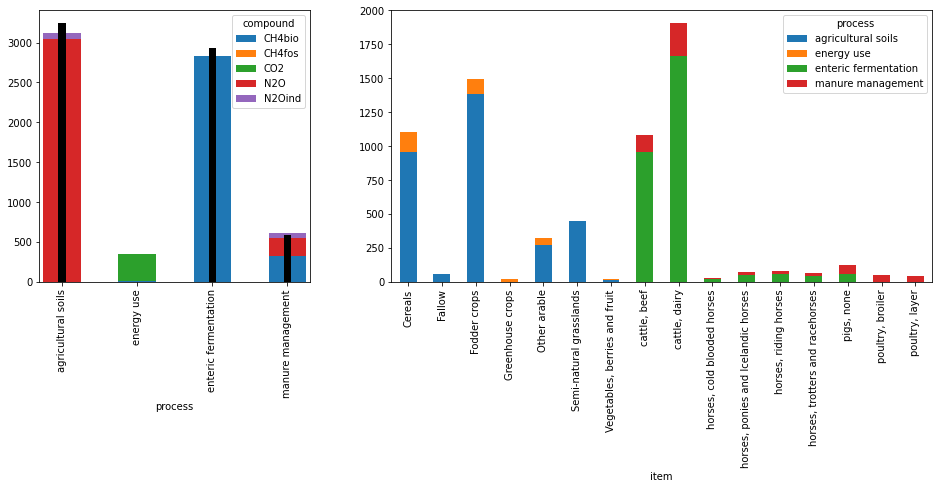

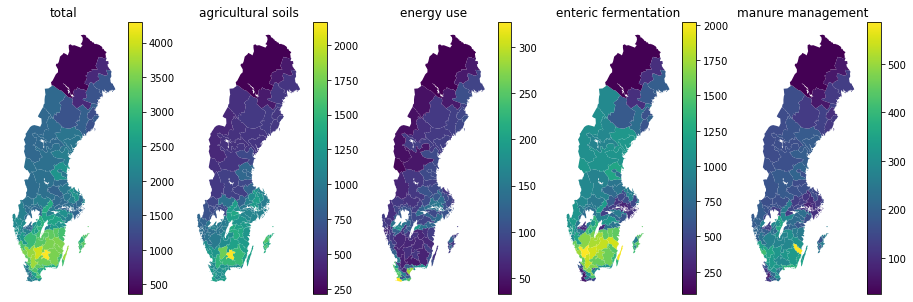

In [74]:
# Bar plot [1000 tonnes CO2eq] ----->
fig, axs = plt.subplots(1,2, figsize=(16,5), gridspec_kw={'width_ratios': [1, 2]})

plot_data = (
    get_GHG(output)
    .sum()
    .groupby(['process','compound'])
    .sum()
    .unstack()
    /1000000
)
plot_data_NIR = pd.Series(
    [3250,0,2930,590],
    index=pd.Index(['agricultural soils','energy use','enteric fermentation','manure management'], name='process')
)
ax=axs[0]
plot_data.plot.bar(stacked='True', ax=ax)
plot_data_NIR.plot.bar(stacked='True', ax=ax, width=0.1, color='black')

plot_data = (
    get_GHG(output)
    .sum()
    .groupby(['item','process'])
    .sum()
    .unstack()
    /1000000
)
ax = axs[1]
plot_data.plot.bar(stacked='True', ax=ax)

plt.show()

# Maps [kg CO2eq/ha] ----->
rel = cm.ParameterRetriever.get_rel('crop','land_use')
area = output.loc[(scn,year),'crp'].area.to_frame()
area['lu'] = [rel[c] for c in area.index.get_level_values('crop')]
area = (
    area.loc[area['lu'].isin(['cropland','semi-natural grasslands']),0]
    .groupby('region')
    .sum()
)

plot_data = (
    get_GHG(output)
    .groupby('process', axis=1)
    .sum()
    .mul(1/area, axis=0)
)

fig, axs = plt.subplots(1,5, figsize=(16,5))
ax = axs[0]
plot.map_from_series(plot_data.sum(axis=1), ax=ax)
ax.set_title('total')
ax.axis('off')
i = 1
for proc in plot_data.columns:
    ax = axs[i]
    plot.map_from_series(plot_data[proc], ax=ax)
    ax.set_title(proc)
    ax.axis('off')
    i += 1
plt.show()

### Check deviations from x0

In [75]:
print('Crops max(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).max())
print('Crops min(x-x0) [ha]:',(geodist.x['crp'] - geodist.x0['crp']).min())
print('Animals max(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).max())
print('Animals min(x-x0) [nr]:',(geodist.x['ani'] - geodist.x0['ani']).min())

Crops max(x-x0) [ha]: 10312.02033127545
Crops min(x-x0) [ha]: -11476.20127614971
Animals max(x-x0) [nr]: 18618.468630924603
Animals min(x-x0) [nr]: -408130.0342029815


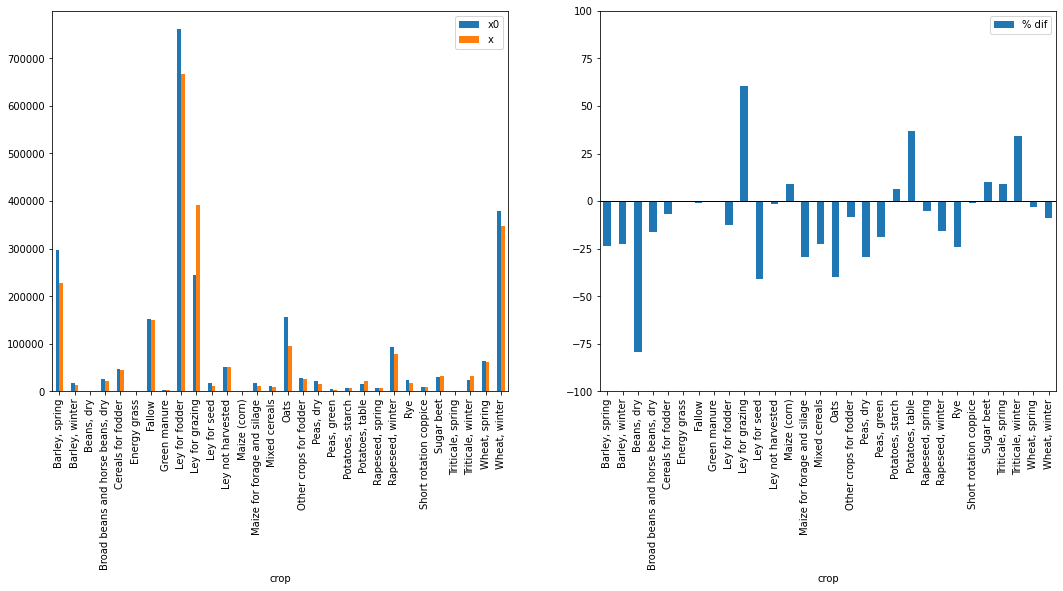

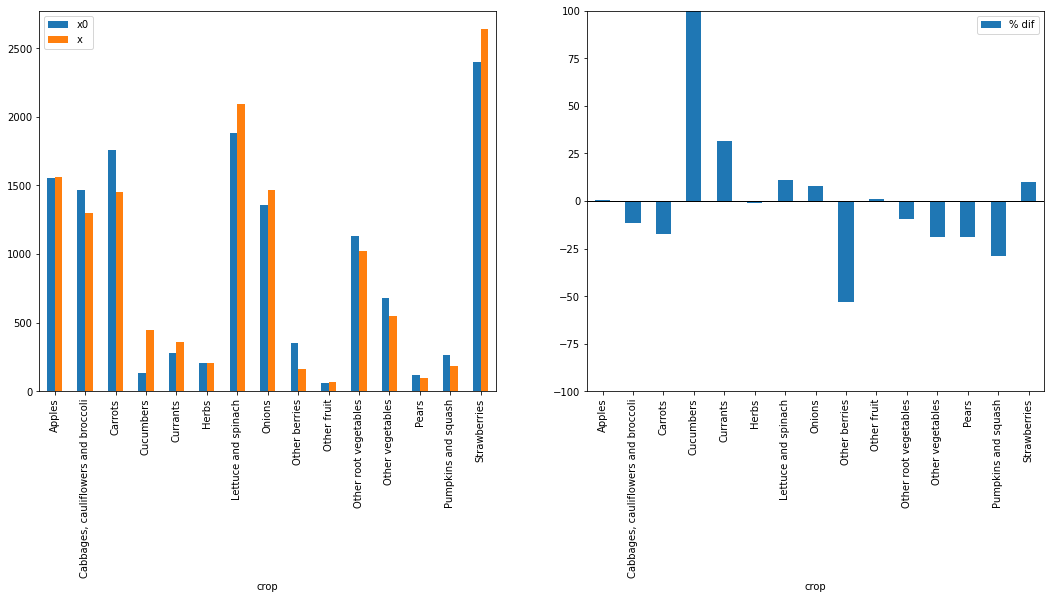

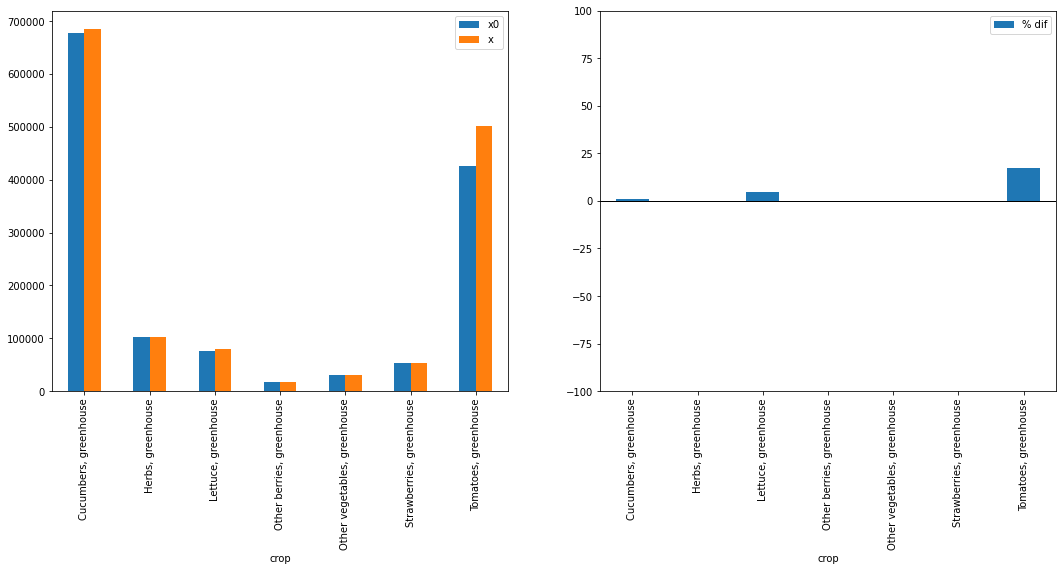

In [76]:
plot_data = (
    pd.concat([
        output.loc[('none','2020'),'crp'].area.groupby('crop').sum().rename('x'),
        geodist.x0['crp'].groupby('crop').sum().rename('x0')
    ], axis=1)
    .apply(
        lambda x:
        pd.Series(
            [
                x['x'],
                x['x0'],
                ((x['x']-x['x0'])/x['x0']*100)
            ],
            index = ['x','x0','% dif']
        ),
        axis=1
    )
)

cg_dict = crops.par.get_rel('crop','crop_group')
plot_data['cg'] = [cg_dict[c] for c in plot_data.index.get_level_values(0)]

hr = ['Vegetables','Berries','Fruit trees']
gh = ['Vegetables, greenhouse','Berries, greenhouse']
sng = ['Semi-natural grasslands']

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[~plot_data['cg'].isin(hr+gh+sng)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[~plot_data['cg'].isin(hr+gh+sng)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[plot_data['cg'].isin(hr)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[plot_data['cg'].isin(hr)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data[plot_data['cg'].isin(gh)].plot.bar(y=['x0','x'], ax=axs[0])
plot_data[plot_data['cg'].isin(gh)].plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

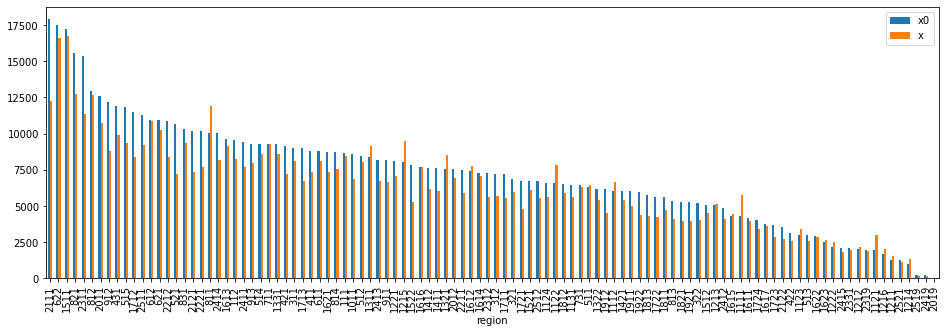

In [77]:
crp = 'Ley for fodder'

fig, ax = plt.subplots(figsize=(16,5))

pd.concat([
    geodist.x0['crp'].xs(crp, level='crop').groupby('region').sum().rename('x0'),
    output.loc[('none','2020'),'crp'].area.xs(crp, level='crop').groupby('region').sum().rename('x')
], axis=1).sort_values('x0', ascending=False).plot.bar(ax=ax)

plt.show()

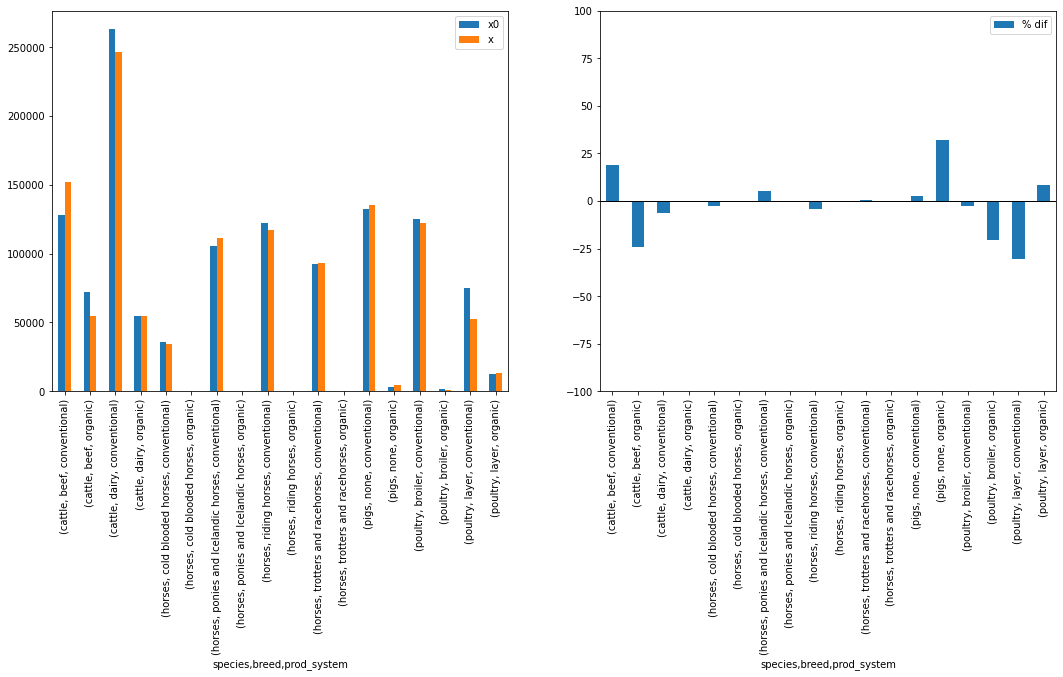

In [78]:
idx = pd.IndexSlice

plot_data = (
    pd.concat([
        output.loc[('none','2020'),'ani'].heads
        .loc[:,idx[:,:,:,:,[
            'cows','sows','gilts','broodmares','low-performing horses',
            'medium-performing horses','young horses','broilers','laying hens (16-28 weeks)',
            'laying hens (29-59 weeks)','laying hens (>59 weeks)','breeding hens and roosters'
        ]]]
        .groupby(['species','breed','prod_system'], axis=1).sum()
        .sum()
        .rename('x')
        ,
        geodist.x0['ani']
        .groupby(['species','breed','prod_system']).sum()
        .rename('x0')
    ], axis=1)
)
# Adjust poultry to 100 heads
plot_data = \
plot_data.mul(np.where(plot_data.index.get_level_values('species')=='poultry',1/100,1), axis=0)
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, axs = plt.subplots(1,2, figsize=(18,7))
plot_data.plot.bar(y=['x0','x'], ax=axs[0])
plot_data.plot.bar(y='% dif', ax=axs[1])
plt.axhline(y=0, c='black', lw=1)
axs[1].set_ylim(-100,100)
plt.show()

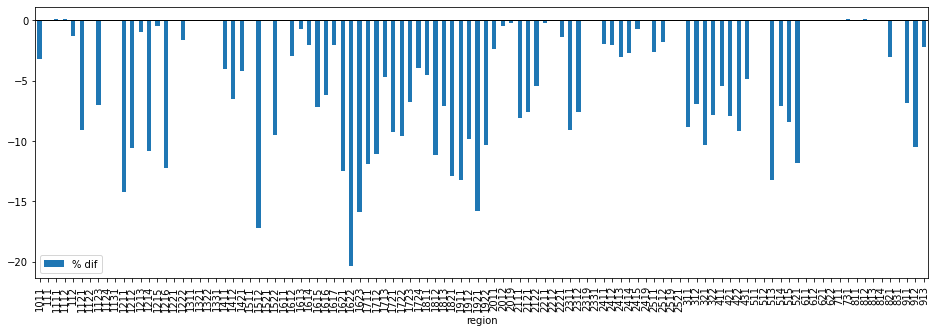

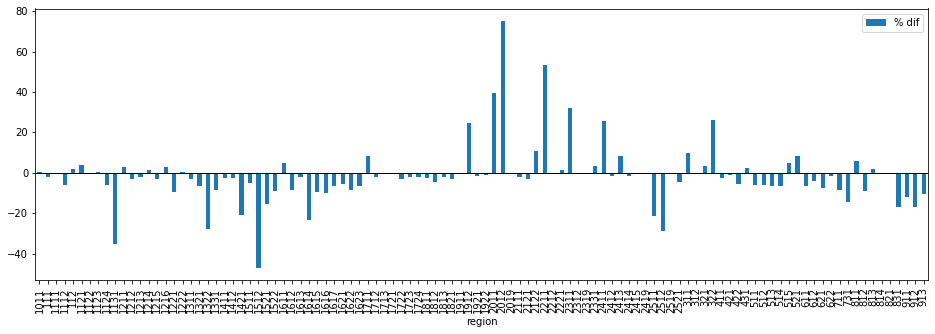

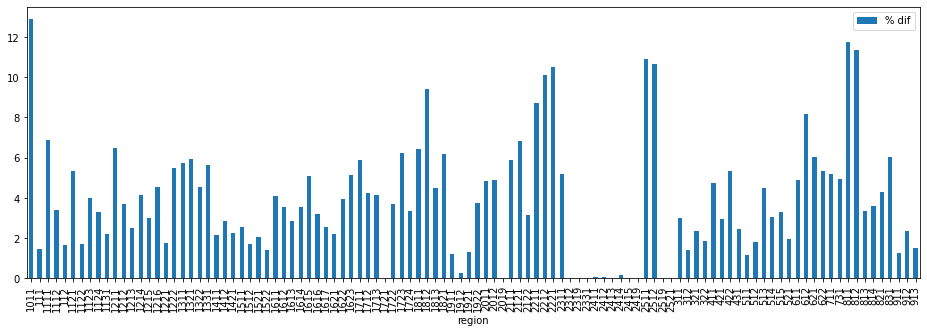

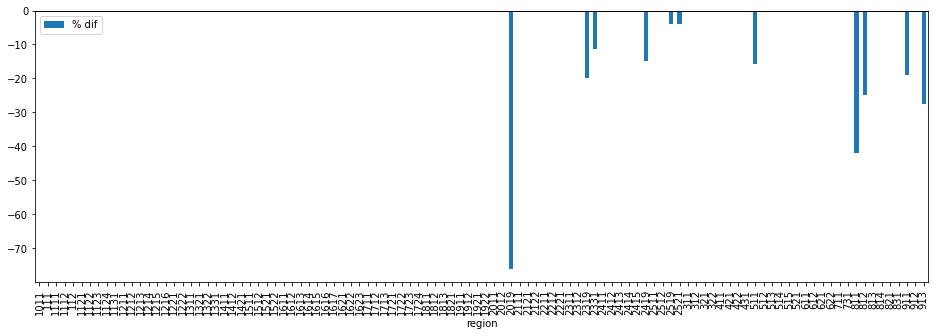

In [79]:

plot_data_ = (pd.concat([
    output.loc[('none','2020'),'crp'].area.groupby(['crop','region']).sum().rename('x'),
    geodist.x0['crp'].groupby(['crop','region']).sum().rename('x0')
], axis=1)
)

cg_dict = crops.par.get_rel('crop','crop_group')
plot_data_['cg'] = [cg_dict[c] for c in plot_data_.index.get_level_values('crop')]

hr = ['Vegetables','Berries','Fruit trees']
gh = ['Vegetables, greenhouse','Berries, greenhouse']
sng = ['Semi-natural grasslands']

# Crops
plot_data = plot_data_.loc[~plot_data_['cg'].isin(hr+gh+sng)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.show()

# Horti
plot_data = plot_data_.loc[plot_data_['cg'].isin(hr)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.show()

# Greenhouse
plot_data = plot_data_.loc[plot_data_['cg'].isin(gh)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.show()

# Semi-natural grasslands
plot_data = plot_data_.loc[plot_data_['cg'].isin(sng)].groupby('region').sum()
plot_data['% dif'] = (plot_data['x']-plot_data['x0'])/plot_data['x0']*100

fig, ax = plt.subplots(figsize=(16,5))
plot_data.plot.bar(y='% dif', ax=ax)
plt.axhline(y=0, c='black', lw=1)
plt.show()